In [56]:
from langchain_community.tools import ArxivQueryRun , WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper , ArxivAPIWrapper


In [108]:
api_wrapper_arxiv = ArxivAPIWrapper(top_k_results= 3,doc_content_chars_max = 500 )
arxiv = ArxivQueryRun(api_wrapper= api_wrapper_arxiv, description=" Query arxiv papers")

In [106]:
print(arxiv.invoke("agentic AI systems"))

Published: 2026-03-19
Title: Security, privacy, and agentic AI in a regulatory view: From definitions and distinctions to provisions and reflections
Authors: Shiliang Zhang, Sabita Maharjan
Summary: The rapid proliferation of artificial intelligence (AI) technologies has led to a dynamic regulatory landscape, where legislative frameworks strive to keep pace with technical advancements. As AI paradigms shift towards greater autonomy, specifically in the form of agentic AI, it becomes increasingly challenging to precisely articulate regulatory stipulations. This challenge is even more acute in the domains of security and privacy, where the capabilities of autonomous agents often blur traditional legal and technical boundaries. This paper reviews the evolving European Union (EU) AI regulatory provisions via analyzing 24 relevant documents published between 2024 and 2025. From this review, we provide a clarification of critical definitions. We deconstruct the regulatory interpretations of 

In [63]:
api_wrapper_wiki = WikipediaAPIWrapper(top_k_results=1 , doc_content_chars_max = 500)
wiki =WikipediaQueryRun(api_wrapper= api_wrapper_wiki)

In [64]:
wiki.name

'wikipedia'

In [65]:
p= wiki.invoke("Lata Mangeshkar")

In [66]:
print(p)

Page: Lata Mangeshkar
Summary: Lata Mangeshkar (Hindi pronunciation: [ləˈt̪aː məŋˈɡeːʃkəɾ] ; born Hema Mangeshkar; 28 September 1929 – 6 February 2022) was an Indian playback singer and occasional music composer. She is considered to be one of the greatest and most influential singers of the Indian subcontinent. Her contribution to the Indian music industry in a career spanning eight decades gained her honorific titles such as the "Queen of Melody" and "Voice of the Millennium".
Mangeshkar recor


In [67]:
import os
from dotenv import load_dotenv
load_dotenv()
os.environ["GROQ_API_KEY"]= os.getenv("GROQ_API_KEY")
os.environ["TAVILY_API_KEY"]= os.getenv("TAVILY_API_KEY")

In [69]:
#web search tool
from langchain_tavily import TavilySearch
tavily = TavilySearch()

In [70]:
print(tavily.invoke("what is a quantum computing "))

{'query': 'what is a quantum computing', 'follow_up_questions': None, 'answer': None, 'images': [], 'results': [{'url': 'https://www.nvidia.com/en-us/glossary/quantum-computing/', 'title': 'What is Quantum Computing? - NVIDIA', 'content': 'Quantum computing is a paradigm shifting technology that leverages the laws of quantum physics to solve extremely difficult problems.', 'score': 0.99896777, 'raw_content': None}, {'url': 'https://learn.microsoft.com/en-us/azure/quantum/overview-understanding-quantum-computing', 'title': 'What Is Quantum Computing? - Azure Quantum | Microsoft Learn', 'content': "# What is quantum computing? Since that time, fast and efficient quantum computer algorithms were developed for other problems that are difficult to solve on classical computers. Just as bits are the fundamental object of information in classical computing, qubits (quantum bits) are the fundamental object of information in quantum computing. In quantum computing, information is encoded in supe

In [71]:
tools =[ arxiv , wiki, tavily]

In [72]:
from langchain_groq import ChatGroq
llm = ChatGroq(model ="qwen/qwen3-32b")

In [73]:
llm.invoke("what is Ai")

AIMessage(content='<think>\nOkay, the user is asking "what is AI". I need to explain it in a clear way. Let me start by defining AI. Artificial Intelligence, right? So it\'s the simulation of human intelligence by machines. But maybe I should break it down further. What are the key components of AI? Machine learning, natural language processing, computer vision. Oh, and maybe mention different types like narrow AI and general AI. Wait, the user might not know the difference. Let me make sure to clarify that. Narrow AI is what we use today, like Siri or recommendation systems. General AI is the hypothetical version that can do anything a human can. \n\nI should also talk about applications. AI is used in healthcare, finance, transportation, etc. Maybe give some examples like medical diagnostics, self-driving cars. But the user might be a beginner, so keep it simple. Avoid jargon. Also, mention the technologies involved: neural networks, deep learning, big data. Explain how AI systems le

In [74]:
llm_with_tools = llm.bind_tools(tools)

In [75]:
llm_with_tools.invoke("what is the recent bechmark score of claude opus")

AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, the user is asking for the recent benchmark score of Claude Opus. First, I need to figure out what tools I can use here. The available functions are arxiv, wikipedia, and tavily_search. Since benchmark scores are likely to be recent and specific, arxiv might not have the latest data. Wikipedia is more for general knowledge and might not have up-to-date benchmark results. That leaves tavily_search, which is optimized for current events and can handle specific queries with parameters like date ranges.\n\nI should use tavily_search. The user wants recent scores, so I should set the start_date to a recent date, maybe the last month. Let me check the parameters. The start_date should be in YYYY-MM-DD format. Let\'s say 2023-10-01. Also, the search_depth should be advanced to get thorough results. Maybe include domains like benchmark sites or tech blogs. But the user didn\'t specify domains, so maybe leave include_domains a

In [76]:
## workflow with the help of the langgraph

from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage
from typing import Annotated
from langgraph.graph.message import add_messages

In [77]:
class State(TypedDict):
    messages: Annotated[list[AnyMessage] , add_messages]


In [95]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition

from langgraph.prebuilt import tools_condition


In [96]:
def tool_calling_llm(state : State):
    return {"messages" : [llm_with_tools.invoke(state["messages"])]}


#build graph

builder=  StateGraph(State)
builder.add_node("tool_calling_llm" , tool_calling_llm)
builder.add_node("tools" , ToolNode(tools))

# building the edges


builder.add_edge(START , "tool_calling_llm")
builder.add_conditional_edges("tool_calling_llm",tools_condition )
builder.add_edge("tools", END)


In [97]:
graph = builder.compile()

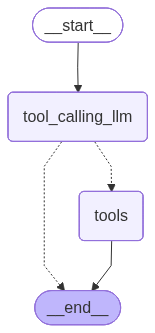

In [98]:
display(graph)

In [102]:
messages= graph.invoke({"messages" : "1706.03762"})
for m in messages["messages"]:
    m.pretty_print()

================================ Human Message =================================

1706.03762
================================== Ai Message ==================================
Tool Calls:
  arxiv (z48hm0gj5)
 Call ID: z48hm0gj5
  Args:
    query: 1706.03762
================================= Tool Message =================================
Name: arxiv

Published: 2023-08-02
Title: Attention Is All You Need
Authors: Ashish Vaswani, Noam Shazeer, Niki P


In [110]:
mess= graph.invoke({"messages" : "hi my name is anmol  just give the research paper on the RAG pipline "})
for m in mess["messages"]:
    m.pretty_print()

================================ Human Message =================================

hi my name is anmol  just give the research paper on the RAG pipline 
================================== Ai Message ==================================
Tool Calls:
  arxiv (4djhhqe4e)
 Call ID: 4djhhqe4e
  Args:
    query: RAG pipeline
================================= Tool Message =================================
Name: arxiv

Published: 2026-02-25
Title: MammoWise: Multi-Model Local RAG Pipeline for Mammography Report Genera
